# Task 1: tune the hyperparameters in that model to improve the accuracy


In [9]:
import math
import pandas as pd
import torch
from torch import nn
import d2l

In [10]:
class PositionWiseFFN(nn.Module):
    """The positionwise feed-forward network."""
    def __init__(self, ffn_num_hiddens, ffn_num_outputs):
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [11]:
ffn = PositionWiseFFN(4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[-0.2311,  0.1571, -0.1317, -0.9279,  0.1909,  0.1429,  0.7355,  0.3346],
        [-0.2311,  0.1571, -0.1317, -0.9279,  0.1909,  0.1429,  0.7355,  0.3346],
        [-0.2311,  0.1571, -0.1317, -0.9279,  0.1909,  0.1429,  0.7355,  0.3346]],
       grad_fn=<SelectBackward0>)

In [12]:
ln = nn.LayerNorm(2)
bn = nn.LazyBatchNorm1d()
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# Compute mean and variance from X in the training mode
print('layer norm:', ln(X), '\nbatch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [13]:
class AddNorm(nn.Module):
    """The residual connection followed by layer normalization."""
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [14]:
add_norm = AddNorm(4, 0.5)
shape = (2, 3, 4)
d2l.check_shape(add_norm(torch.ones(shape), torch.ones(shape)), shape)

In [15]:
class TransformerEncoderBlock(nn.Module):
    """The Transformer encoder block."""
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout,
                 use_bias=False):
        super().__init__()
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                dropout, use_bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [16]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
encoder_blk.eval()
d2l.check_shape(encoder_blk(X, valid_lens), X.shape)

In [17]:
class TransformerEncoder(d2l.Encoder):
    """The Transformer encoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout, use_bias=False):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias))

    def forward(self, X, valid_lens):
        # Since positional encoding values are between -1 and 1, the embedding
        # values are multiplied by the square root of the embedding dimension
        # to rescale before they are summed up
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

In [18]:
encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5)
d2l.check_shape(encoder(torch.ones((2, 100), dtype=torch.long), valid_lens),
                (2, 100, 24))

In [19]:
class TransformerDecoderBlock(nn.Module):
    # The i-th block in the Transformer decoder
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i):
        super().__init__()
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads,
                                                 dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # During training, all the tokens of any output sequence are processed
        # at the same time, so state[2][self.i] is None as initialized. When
        # decoding any output sequence token by token during prediction,
        # state[2][self.i] contains representations of the decoded output at
        # the i-th block up to the current time step
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), dim=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            # Shape of dec_valid_lens: (batch_size, num_steps), where every
            # row is [1, 2, ..., num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        # Self-attention
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        # Encoder-decoder attention. Shape of enc_outputs:
        # (batch_size, num_steps, num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [20]:
decoder_blk = TransformerDecoderBlock(24, 48, 8, 0.5, 0)
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
d2l.check_shape(decoder_blk(X, state)[0], X.shape)

In [21]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, dropout):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerDecoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, i))
        self.dense = nn.LazyLinear(vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # Decoder self-attention weights
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # Encoder-decoder attention weights
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

batch size: helps stabilize training and improve model’s learning efficiency.

NOTE* really large batch sizes can reduce generalization
num of layers/blocks: improved model’s understanding of sentence structure and complex relationships between words within a sentence

fnn increase: improves model’s learning capacity and producing more detailed feature representations

attention heads: allows model to learn multiple relationships between words simultaneously.

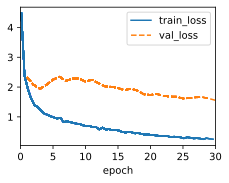

In [22]:
# larger batch size
data = d2l.MTFraEng(batch_size=128)

# Deeper network, wider feed-forward layers, and more attention heads
num_hiddens, num_blks, dropout = 256, 3, 0.2   # Increased blocks to 3
ffn_num_hiddens, num_heads = 256, 8            # Increased FFN size and heads

encoder = TransformerEncoder(
    len(data.src_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)
decoder = TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads,
    num_blks, dropout)

# lower learning rate for stability with a deeper model
model = d2l.Seq2Seq(encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'],
                    lr=0.0005)

# Train for more epochs
trainer = d2l.Trainer(max_epochs=30, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [23]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
preds, _ = model.predict_step(
    data.build(engs, fras), d2l.try_gpu(), data.num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in data.tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu,'
          f'{d2l.bleu(" ".join(translation), fr, k=2):.3f}')

go . => ['va', '!'], bleu,1.000
i lost . => ["j'ai", 'perdu', '.'], bleu,1.000
he's calm . => ['il', 'est', 'mouillé', '.'], bleu,0.658
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], bleu,1.000


Let's [**visualize the Transformer attention weights**] when translating the final English sentence into French.
The shape of the encoder self-attention weights
is (number of encoder layers, number of attention heads, `num_steps` or number of queries, `num_steps` or number of key-value pairs).


In [24]:
_, dec_attention_weights = model.predict_step(
    data.build([engs[-1]], [fras[-1]]), d2l.try_gpu(), data.num_steps, True)
enc_attention_weights = torch.cat(model.encoder.attention_weights, 0)
shape = (num_blks, num_heads, -1, data.num_steps)
enc_attention_weights = enc_attention_weights.reshape(shape)
d2l.check_shape(enc_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

In the encoder self-attention,
both queries and keys come from the same input sequence.
Since padding tokens do not carry meaning,
with specified valid length of the input sequence
no query attends to positions of padding tokens.
In the following,
two layers of multi-head attention weights
are presented row by row.
Each head independently attends
based on a separate representation subspace of queries, keys, and values.


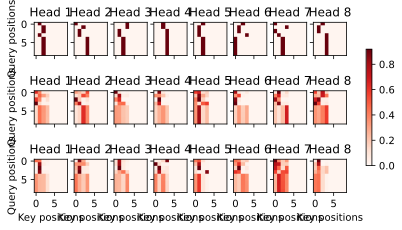

In [25]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 9)],
    figsize=(7, 3.5))

[**To visualize the decoder self-attention weights and the encoder--decoder attention weights,
we need more data manipulations.**]
For example,
we fill the masked attention weights with zero.
Note that
the decoder self-attention weights
and the encoder--decoder attention weights
both have the same queries:
the beginning-of-sequence token followed by
the output tokens and possibly
end-of-sequence tokens.


In [26]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weights
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
shape = (-1, 2, num_blks, num_heads, data.num_steps)
dec_attention_weights = dec_attention_weights_filled.reshape(shape)
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)

In [27]:
d2l.check_shape(dec_self_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))
d2l.check_shape(dec_inter_attention_weights,
                (num_blks, num_heads, data.num_steps, data.num_steps))

Because of the autoregressive property of the decoder self-attention,
no query attends to key--value pairs after the query position.


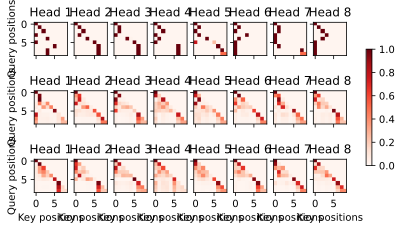

In [28]:
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 9)], figsize=(7, 3.5))

Similar to the case in the encoder self-attention,
via the specified valid length of the input sequence,
[**no query from the output sequence
attends to those padding tokens from the input sequence.**]


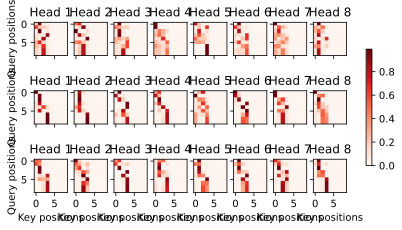

In [29]:
d2l.show_heatmaps(
    dec_inter_attention_weights, xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 9)],
    figsize=(7, 3.5))

# Task 2: Improve the Model (BERT Encoder Hybrid)
For the primary improvement use the standard Transformer encoder from the baseline model with a pre-trained BERT model.

This approach leverages Transfer Learning. Utilize a pre-trained BERT model for its understanding of the English language. Freeze the parameters of the BERT encoder during training. This forces the custom decoder to learn how to map BERT English embeddings into French without disrupting the weights BERT has already learned.

In [30]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from transformers import BertModel, BertTokenizer

### Encoder
Define the custom BERT encoder class that replace the baseline transformer encoder. Initialize bert-base-uncased model and freeze parameters by setting requires_grad to False. This ensures the English language representations remain unchanged during training process.

BERT outputs hidden states with dimension 768. To align this with decoder include a linear projection layer that maps the 768-dimensional embeddings down to 256. For forward pass we route the input tokens through BERT without calculating gradients to save resources.

In [31]:
class BERTEncoder(d2l.Encoder):
    def __init__(self, num_hiddens, **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        # Load pre-trained BERT and freeze its parameters
        # so we only train the decoder.
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False

        # Projection layer to map BERT's 768-dim down to the decoder's expected 256-dim hidden size.
        self.projection = nn.Linear(768, num_hiddens)

    def forward(self, X, valid_lens, *args):
        # Pass English tokens through BERT
        with torch.no_grad():
            outputs = self.bert(X)
        encoded_X = outputs.last_hidden_state
        return self.projection(encoded_X)

### Data Preprocessing
For BERT, the English source text must be tokenized. Use Hugging Face BertTokenizer to align with the vocabulary, padding, and truncation that BERT needs. French target text is processed using the baseline vocabulary since the decoder is trained from scratch.

Construct the decoder inputs by applying teacher forcing—shifting the target sequence and inserting a beginning-of-sequence token. Package into PyTorch TensorDataset and skip the default data loader.

In [32]:
# Intercept d2l pipeline to tokenize English source text with HuggingFace's BertTokenizer instead of the d2l vocab.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
raw_text = d2l.read_data_nmt()
text = d2l.preprocess_nmt(raw_text)
src_sentences, tgt_sentences = d2l.tokenize_nmt(text, num_examples=data.num_train)

# Tokenize English source with BERT
src_joined = [' '.join(s) for s in src_sentences]
encoded_src = tokenizer(src_joined, padding='max_length', max_length=data.num_steps, truncation=True, return_tensors='pt')
src_array, src_valid_len = encoded_src['input_ids'], encoded_src['attention_mask'].sum(dim=1)

# Process French target with standard d2l vocab
tgt_array, tgt_valid_len = d2l.build_array_nmt(tgt_sentences, data.tgt_vocab, data.num_steps)

# Construct Teacher Forcing Decoder Input (adds <bos> token)
bos_column = torch.tensor([data.tgt_vocab['<bos>']] * len(tgt_array)).reshape(-1, 1)
dec_X = torch.cat([bos_column, tgt_array[:, :-1]], dim=1)

# Override the standard d2l train_dataloader with our hybrid dataset
dataset = TensorDataset(src_array, dec_X, src_valid_len, tgt_array)
data.train_dataloader = lambda: DataLoader(dataset, batch_size=128, shuffle=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Training
Use BERT encoder and a Transformer decoder to form a complete sequence-to-sequence model.

Use gradient clipping to stabilize the training. Use GPU to accelerate computation. Run fit to translate BERT's English representations into French, the encoder weights stay frozen.

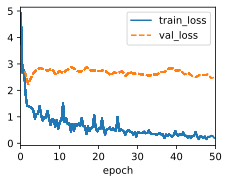

In [33]:
bert_encoder = BERTEncoder(num_hiddens=num_hiddens)
decoder = TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
bert_model = d2l.Seq2Seq(bert_encoder, decoder, tgt_pad=data.tgt_vocab['<pad>'], lr=0.0005)

trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(bert_model, data)

### Inference and Translation
Translate the new English sentences using the hybrid architecture. Because our encoder uses on BERT the incoming testing strings have to be tokenized. Use Hugging Face BERT tokenizer so the input format matches what the frozen encoder expects.

Don't tracking gradients. The model passes the tokenized English through the BERT encoder to get contextual embeddings to initialize the decoder. The decoder generates the French translation autoregressively until it predicts the end-of-sequence token.

In [34]:
# Bypasses the built-in predict function to tokenize the testing strings with BERT before translating.
def predict_bert(model, eng_sentence, tgt_vocab, num_steps, device):
    model.eval()
    encoded = tokenizer(eng_sentence, padding='max_length', max_length=num_steps, truncation=True, return_tensors='pt').to(device)
    enc_X, enc_valid_len = encoded['input_ids'], encoded['attention_mask'].sum(dim=1)

    with torch.no_grad():
        enc_outputs = model.encoder(enc_X, enc_valid_len)
        dec_state = model.decoder.init_state(enc_outputs, enc_valid_len)
        dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
        output_seq = []
        for _ in range(num_steps):
            Y, dec_state = model.decoder(dec_X, dec_state)
            dec_X = Y.argmax(dim=2)
            pred = dec_X.squeeze(dim=0).type(torch.int32).item()
            if pred == tgt_vocab['<eos>']:
                break
            output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq))

In [35]:
device = d2l.try_gpu()
print("--- Task 2: BERT Hybrid Results ---")
for eng, fra in zip(engs, fras):
    translation = predict_bert(bert_model, eng, data.tgt_vocab, data.num_steps, device)
    print(f'{eng} => {translation}, bleu {d2l.bleu(translation, fra, k=2):.3f}')

--- Task 2: BERT Hybrid Results ---
go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est mouillé ., bleu 0.658
i'm home . => je suis chez moi ., bleu 1.000


# TASK 3: BIBLICAL GREEK TO ENGLISH

Here the same hybrid architecture is used to translate Biblical Greek into English. Using and cleaned a dataset from [kevinkrahn](https://github.com/kevinkrahn/ancient-greek-datasets). Used encoder [pranaydeeps/Ancient-Greek-BERT](https://huggingface.co/pranaydeeps/Ancient-Greek-BERT)

In [36]:
import torch
from torch import nn
from torch.utils.data import TensorDataset
from transformers import AutoTokenizer, AutoModel
import d2l

### Ancient Greek Encoder
A custom encoder for translating Biblical Greek. The code loads a pre-trained Ancient Greek BERT model and freezes the network weights to preserve specialized language representations. A linear layer projects the 768-dimensional output down to the expected hidden size of the decoder. An attention mask applied during the forward pass ensures the encoder correctly ignores padding tokens.

In [37]:
# https://huggingface.co/pranaydeeps/Ancient-Greek-BERT
class AncientGreekBERTEncoder(d2l.Encoder):
    def __init__(self, num_hiddens, **kwargs):
        super(AncientGreekBERTEncoder, self).__init__(**kwargs)
        # Load the pre-trained Ancient Greek BERT
        self.bert = AutoModel.from_pretrained("pranaydeeps/Ancient-Greek-BERT")

        # Freeze the weights so we only train the decoder
        for param in self.bert.parameters():
            param.requires_grad = False

        # Project the 768-dimensional BERT output down to our 256-dim decoder
        self.projection = nn.Linear(768, num_hiddens)

    def forward(self, X, valid_lens, *args):
        # Create attention mask so BERT ignores <pad> tokens
        mask = torch.arange(X.shape[1], device=X.device)[None, :] < valid_lens[:, None]
        with torch.no_grad():
            outputs = self.bert(input_ids=X, attention_mask=mask.long())
        return self.projection(outputs.last_hidden_state)

### Data Preprocessing
Data ingestion and preprocessing for the Greek-to-English dataset. The code reads tab-delimited translation pairs from a text file of source and target sentences. The Greek text is tokenized using the specialized Ancient Greek BERT tokenizer to match the frozen encoder, while the English text is processed into a standard vocabulary. Apply teacher forcing to the target sequences. The formatted data is put into a PyTorch DataLoader and a custom wrapper class for compatibility with the training pipeline.

In [38]:
tokenizer = AutoTokenizer.from_pretrained("pranaydeeps/Ancient-Greek-BERT")

# Load the training file (translation_pairs_a.txt)
# https://github.com/kevinkrahn/ancient-greek-datasets
with open('translation_pairs_a.txt', 'r', encoding='utf-8') as f:
    raw_train_lines = f.readlines()[:5000]

greek_sentences, english_sentences = [], []
for line in raw_train_lines:
    parts = line.strip().split('\t') # tab seporators
    if len(parts) == 2:
        greek_sentences.append(parts[0].lower())
        english_sentences.append(parts[1].lower().split(' '))

# Use min_freq=2 to keep the vocabulary size manageable - Not Used
tgt_vocab = d2l.Vocab(english_sentences, min_freq=0, reserved_tokens=['<pad>', '<bos>', '<eos>'])
num_steps = 20

# Tokenize the data
encoded_src = tokenizer(greek_sentences, padding='max_length', max_length=num_steps, truncation=True, return_tensors='pt')
src_array, src_valid_len = encoded_src['input_ids'], encoded_src['attention_mask'].sum(dim=1)
tgt_array, tgt_valid_len = d2l.build_array_nmt(english_sentences, tgt_vocab, num_steps)

# Teacher Forcing (adding <bos> to the front of the target sequence)
bos_column = torch.tensor([tgt_vocab['<bos>']] * len(tgt_array)).reshape(-1, 1)
dec_X = torch.cat([bos_column, tgt_array[:, :-1]], dim=1)

# Create the Dataloader
dataset = TensorDataset(src_array, dec_X, src_valid_len, tgt_array)
class GreekDataWrapper:
    def __init__(self, dataloader, tgt_vocab, num_steps):
        # Use lambda to turn the objects into callable functions for d2l
        self.train_dataloader = lambda: dataloader
        self.val_dataloader = lambda: None
        self.tgt_vocab = tgt_vocab
        self.num_steps = num_steps

# Batch size is 128 (reduce to 64 if low GPU memory)
greek_data = GreekDataWrapper(DataLoader(dataset, batch_size=128, shuffle=True), tgt_vocab, num_steps)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### Training
The hyperparameters and assembles the complete sequence-to-sequence architecture. The custom Ancient Greek BERT encoder is paired with a standard Transformer decoder. A training loop is executed over 150 epochs. It uses gradient clipping and GPU acceleration to train the model.

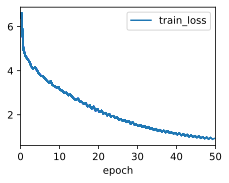

In [39]:
device = d2l.try_gpu()

num_hiddens, num_blks, dropout = 256, 3, 0.2
ffn_num_hiddens, num_heads = 256, 8

greek_encoder = AncientGreekBERTEncoder(num_hiddens=num_hiddens)
decoder = TransformerDecoder(len(tgt_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
greek_model = d2l.Seq2Seq(greek_encoder, decoder, tgt_pad=tgt_vocab['<pad>'], lr=0.0005)

trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(greek_model, greek_data)

### Predict/Translation
The prediction function for translating Biblical Greek. The input text is processed using the Ancient Greek BERT tokenizer for compatibility with the frozen encoder. It operats in evaluation mode without tracking gradients. The sequence passes through the encoder to generate embeddings. These embeddings initialize the decoder. This generates the English translation one token at a time until reaching the end-of-sequence marker.

In [40]:
def predict_ancient_greek(model, grk_sentence, tgt_vocab, num_steps, device):
    model.eval()
    encoded = tokenizer(grk_sentence.lower(), padding='max_length', max_length=num_steps, truncation=True, return_tensors='pt')
    enc_X = encoded['input_ids'].to(device)
    enc_valid_len = encoded['attention_mask'].sum(dim=1).to(device)

    with torch.no_grad():
        enc_outputs = model.encoder(enc_X, enc_valid_len)
        dec_state = model.decoder.init_state(enc_outputs, enc_valid_len)
        dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
        output_seq = []
        for _ in range(num_steps):
            Y, dec_state = model.decoder(dec_X, dec_state)
            dec_X = Y.argmax(dim=2)
            pred = dec_X.squeeze(dim=0).type(torch.int32).item()
            if pred == tgt_vocab['<eos>']: break
            output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq))

### Evaluation
Evaluates the trained Biblical Greek translation model. The code loads sample sentence pairs from a testing file and John 1:1. For each Greek sentence the prediction function generates an English translation. The output displays the predictediont and calculates the BLEU score.

In [41]:
test_greek, test_english = [], []
try:
    with open('translation_pairs_eval.txt', 'r', encoding='utf-8') as f:
        eval_lines = f.readlines()
        for line in eval_lines[:5]: # Grab the first 5 lines for testing
            parts = line.strip().split('\t')
            if len(parts) == 2:
                test_greek.append(parts[0])
                test_english.append(parts[1])
except FileNotFoundError:
    print("Could not find translation_pairs_eval.txt.")
test_greek.append("Ἐν ἀρχῇ ἦν ὁ λόγος, καὶ ὁ λόγος ἦν πρὸς τὸν θεόν, καὶ θεὸς ἦν ὁ λόγος")
test_english.append("in the beginning was the word and the word was with god and the word was god")

print("\nFinal BLEU Score")
for grk, eng in zip(test_greek, test_english):
    translation = predict_ancient_greek(greek_model, grk, tgt_vocab, num_steps, device)
    print(f'\nGreek: {grk}')
    print(f'Predicted: {translation}')
    print(f'Actual: {eng.lower()}')
    print(f'BLEU: {d2l.bleu(translation, eng.lower(), k=2):.3f}')


Final BLEU Score

Greek: Ὁ κήπος γεμίζει ἀνθοῖς.
Predicted: the universe is called technical
Actual: the garden is filled with flowers.
BLEU: 0.000

Greek: Ἡ γυνὴ ἔφαγεν ἄρτον καὶ τυρόν.
Predicted: she is a woman broad daylight and the animate and the tongue.
Actual: the woman ate bread and cheese.
BLEU: 0.000

Greek: Ὁ ναὸς ἐστιν μεγάλος καὶ καλός.
Predicted: the city is called the truth.
Actual: the temple is big and beautiful.
BLEU: 0.000

Greek: Τὸ βιβλίον διδάσκει πολλά.
Predicted: beauty another’s to be done.
Actual: the book teaches many things.
BLEU: 0.000

Greek: Ἡ νύξ φέρει τὴν ἡσυχίαν.
Predicted: the stomach is the term of the term of the term is unlimited.
Actual: the night brings tranquility.
BLEU: 0.000

Greek: Ἐν ἀρχῇ ἦν ὁ λόγος, καὶ ὁ λόγος ἦν πρὸς τὸν θεόν, καὶ θεὸς ἦν ὁ λόγος
Predicted: the first was the question to the question to the question which sets forth of the world, the world, the
Actual: in the beginning was the word and the word was with god and the word w